In [19]:
pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install matplotlib


SyntaxError: invalid syntax (370712082.py, line 1)

In [3]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
-O fonts/NanumGothic.ttf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)
texts = pd.DataFrame({
    '장르': genre,
'어절수': words,
'음절수': syllables,
'읽기시간': read_time,
'난이도': difficulty,
})
# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
'연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
'뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
'소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})


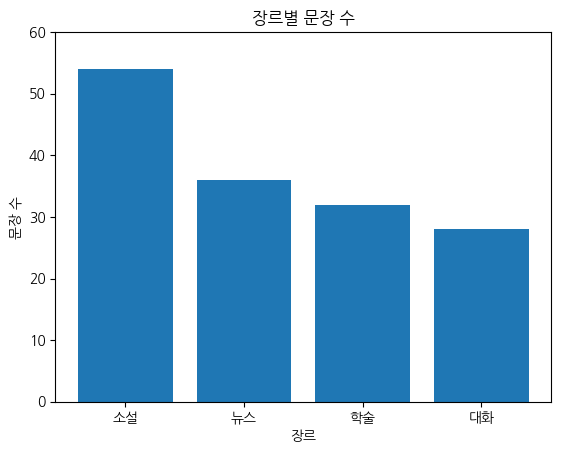

In [7]:
#Q1 (a)
fig, ax = plt.subplots()
counts = (texts['장르'].value_counts())
ax.bar(counts.index, counts.values)
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수') 
ax.set_ylim(0, 60)
plt.show()

코드 설명
value_counts()로 장르별 빈도를 집계하고 ax.bar()로 막대 그래프를 그린다. set_ylim()을 통해 y축을 0부터 시작하도록 설정하였다.

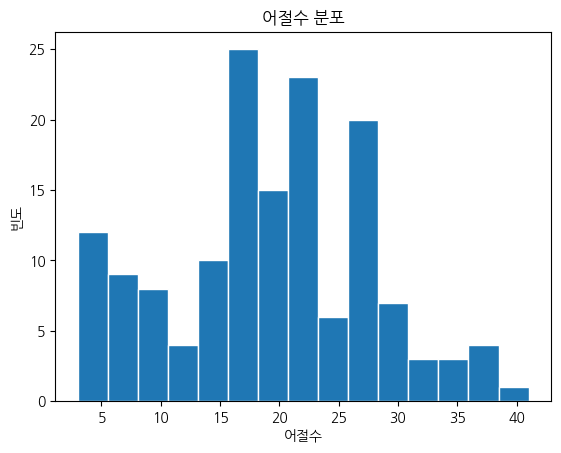

In [8]:
#Q1 (b)
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')
ax.set_title('어절수 분포')
ax.set_xlabel('어절수')
ax.set_ylabel('빈도')
plt.show()

코드 설명
ax.hist()를 사용하여 '어절수' 데이터의 분포를 히스토그램으로 그린다. bins=15로 전체 데이터를 15개 구간으로 나누고, edgecolor='white'를 통해 막대 간의 경계를 뚜렷하게 구분하였다.

관찰
어절 수는 주로 15에서 30 구간 사이에 가장 많이 몰려 있다.

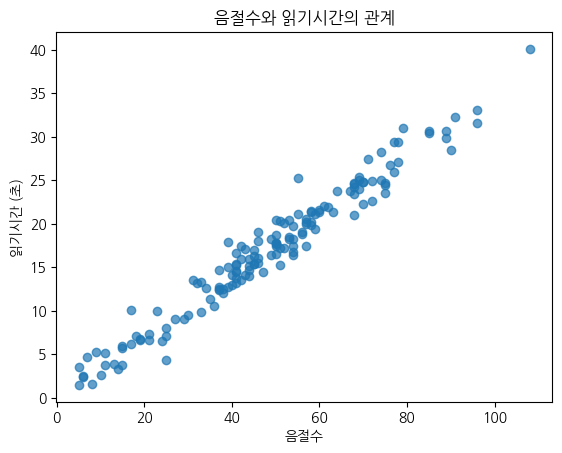

In [9]:
#Q1 (c)
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.7)
ax.set_title('음절수와 읽기시간의 관계')
ax.set_xlabel('음절수')
ax.set_ylabel('읽기시간 (초)')
plt.show()

코드 설명
ax.scatter()를 사용하여 음절수와 읽기시간 두 숫자 변수의 관계를 산점도로 그린다. 점이 겹쳐도 데이터의 밀도를 확인할 수 있도록 alpha 속성으로 투명도를 설정하였다.

관찰
음절수가 늘어날수록 읽기시간도 함께 길어지는 뚜렷한 양의 상관 관계를 보인다.

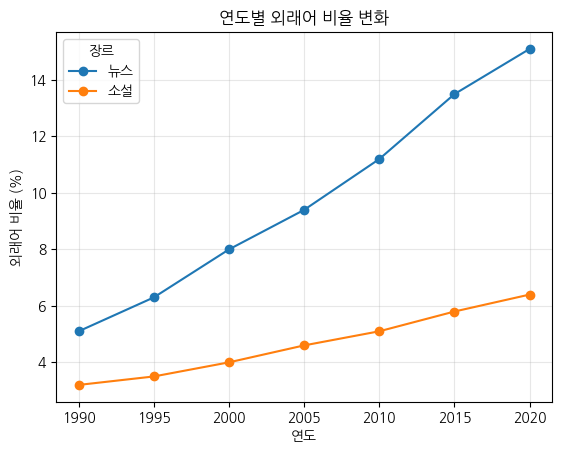

In [12]:
#Q2 (a)
fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='o', label='소설')
ax.set_title('연도별 외래어 비율 변화')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율 (%)')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
plt.show()

코드 설명
ax.plot()을 사용하여 연도에 따른 뉴스와 소설의 외래어 비율 변화를 각각 선 그래프로 그린다. 각 선에 label을 부여한 뒤 ax.legend()로 범례를 나타내고, ax.grid()를 통해 배경에 옅은 격자를 표시하였다.

관찰
두 장르 모두 시간이 지남에 따라 외래어 비율이 증가하고 있으며, 소설에 비해 뉴스의 외래어 비율 증가 폭이 훨씬 가파르다.

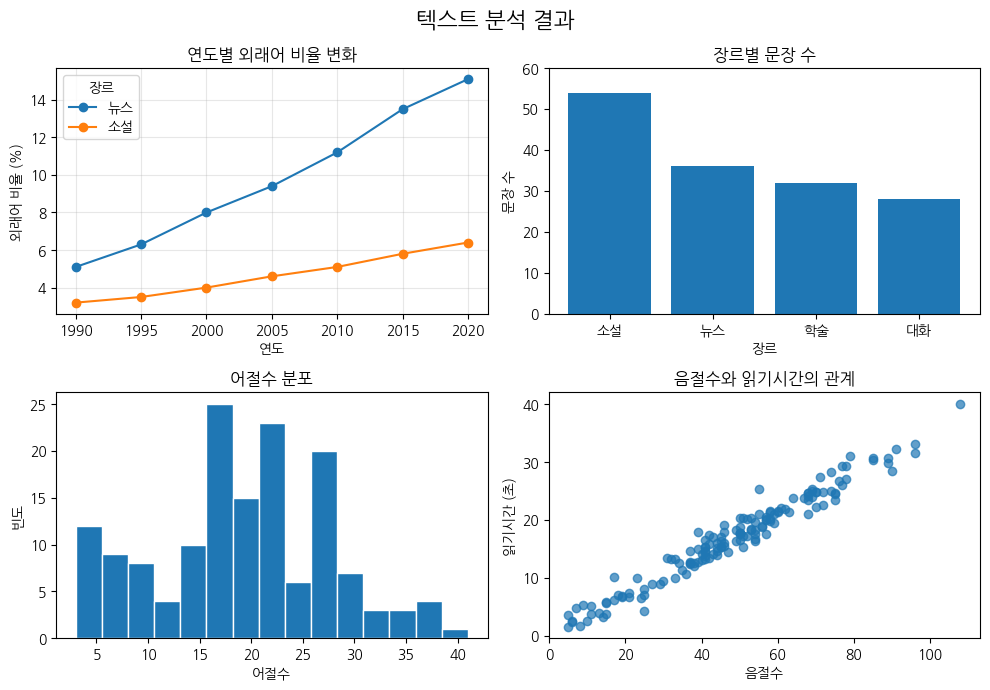

In [ ]:
#Q2 (b)
fig, axes = plt.subplots(2, 2, figsize=(10,7))

axes[0,0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0,0].plot(trends['연도'], trends['소설'], marker='o', label='소설')
axes[0,0].set_title('연도별 외래어 비율 변화')
axes[0,0].set_xlabel('연도')
axes[0,0].set_ylabel('외래어 비율 (%)')
axes[0,0].legend(title='장르')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].bar(counts.index, counts.values)
axes[0,1].set_title('장르별 문장 수')
axes[0,1].set_xlabel('장르')
axes[0,1].set_ylabel('문장 수') 
axes[0,1].set_ylim(0, 60)

axes[1,0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1,0].set_title('어절수 분포')
axes[1,0].set_xlabel('어절수')
axes[1,0].set_ylabel('빈도')

axes[1,1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.7)
axes[1,1].set_title('음절수와 읽기시간의 관계')
axes[1,1].set_xlabel('음절수')
axes[1,1].set_ylabel('읽기시간 (초)')

fig.suptitle('텍스트 분석 결과', fontsize=16)
fig.tight_layout()

fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

코드 설명
subplots(2, 2)를 통해 2차원 배열 형태의 Axes 4개를 생성하고 axes[행, 열] 인덱싱을 통해 각각의 그래프를 배치한다. fig.suptitle()로 전체 제목을 달고, fig.tight_layout()으로 그래프 간 겹침을 방지한 후 savefig()를 이용해 지정된 해상도와 여백 자르기 옵션으로 저장한다.

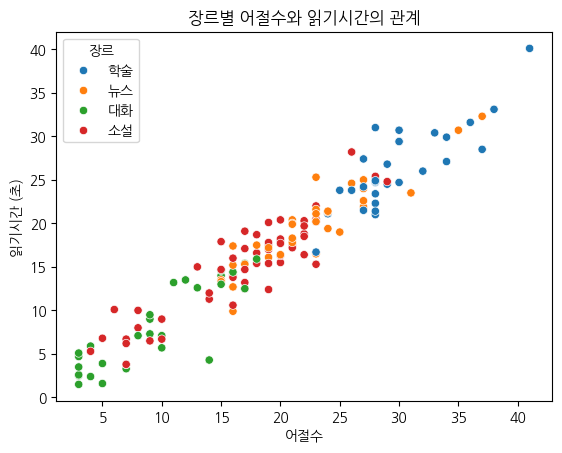

In [30]:
#Q3 (a)
import seaborn as sns
fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', ax=ax)
ax.set_title('장르별 어절수와 읽기시간의 관계')
ax.set_xlabel('어절수')
ax.set_ylabel('읽기시간 (초)')
plt.show()

코드 설명
sns.scatterplot()을 사용하여 어절수와 읽기시간의 관계를 그린다. hue='장르' 인자를 설정하여 장르별로 점의 색상을 자동으로 다르게 칠하고 범례를 생성하며, ax=ax를 통해 미리 만들어둔 그래프 영역에 결과물을 표시한다.

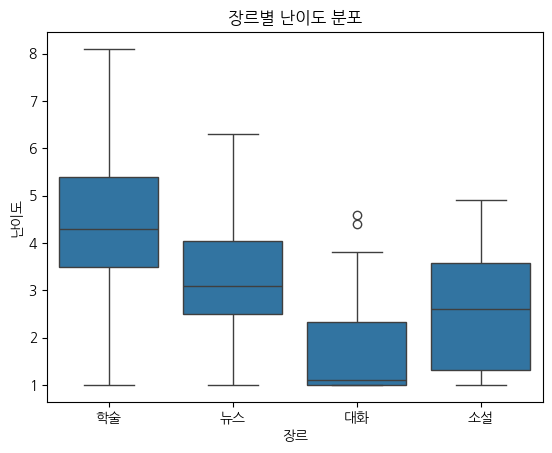

In [31]:
#Q3 (b)
fig, ax = plt.subplots()
sns.boxplot (data=texts, x='장르', y='난이도', ax=ax)
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.show()


코드 설명
sns.boxplot()을 사용하여 범주형 데이터인 '장르'별 '난이도' 분포를 상자그림으로 그린다. ax=ax 인자를 전달하여 미리 생성한 Axes 객체 위에 그래프를 연동한다.

관찰
중앙값이 가장 높게 위치한 '학술' 장르의 난이도가 가장 높으며, 데이터의 퍼짐을 나타내는 상자의 위아래 길이가 가장 긴 장르는 '소설'이다.

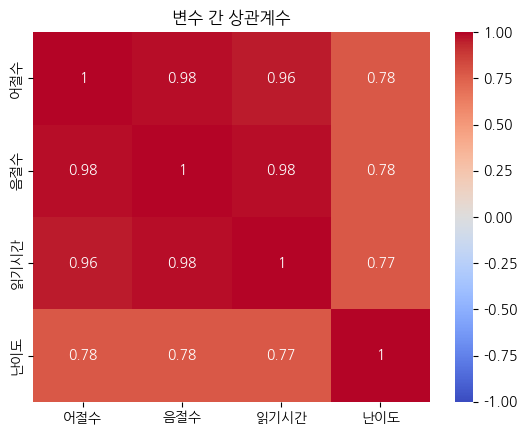

In [26]:
#Q3 (c)
fig, ax = plt.subplots()
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

코드 설몀
corr() 메서드로 네 숫자 변수 간의 상관계수 행렬을 계산한다. 계산된 행렬을 sns.heatmap()에 전달하여 상관계수를 색상과 숫자로 한눈에 나타낸다. vmin=-1과 vmax=1로 양의 상관관계와 음의 상관관계 색상 기준을 명확히 고정하였다

관찰
'어절수'와 '음절수', 그리고 '음절수'와 '읽기시간'이 가장 강하게 함께 증가하는 변수들이다 (상관계수가 +1에 가까움). 문장을 구성하는 단어(어절)가 많을수록 전체 글자(음절) 수가 늘어나는 것은 언어적 특성상 당연하며, 읽어야 할 전체 글자 수가 많아질수록 읽는 데 소요되는 시간 역시 정비례하여 길어지기 때문이다.

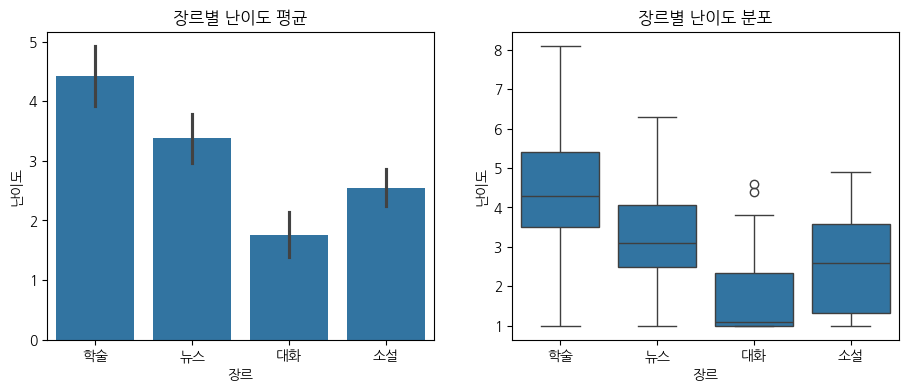

In [32]:
# Q4 (a)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도 평균')
sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포')
plt.show()


코드 설명
subplots(1, 2)를 사용하여 한 줄에 두 개의 그래프 칸을 나란히 배치한다. 왼쪽 영역에는 sns.barplot()으로 장르별 난이도의 평균을 그리고, 오른쪽 영역에는 sns.boxplot()으로 난이도 데이터의 전체적인 분포를 상자그림으로 나타낸다.

서술
왼쪽 막대 그래프는 평균치만 보여줄 뿐, 실제 데이터의 퍼짐 정도와 이상치 정보를 완벽히 숨긴다. 두 장르의 평균 난이도가 같더라도, 한 장르는 정규분포처럼 평균 근처에 몰려 있고 다른 장르는 아주 높거나 낮은 난이도로 넓게 퍼진 치우친 분포일 수 있는데, 상자그림을 그려야만 이러한 진짜 분포의 차이를 확인할 수 있다.

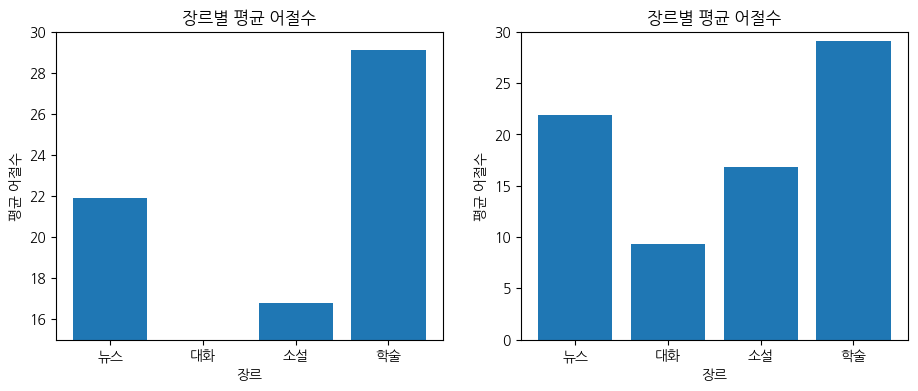

In [29]:
#Q4 (b)
mean = texts.groupby('장르')['어절수'].mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(mean.index, mean.values)
axes[0].set_title('장르별 평균 어절수')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('평균 어절수')
axes[0].set_ylim(15, 30)

axes[1].bar(mean.index, mean.values)
axes[1].set_title('장르별 평균 어절수')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('평균 어절수')
axes[1].set_ylim(0, 30)

plt.show()

코드 설명
groupby()를 사용하여 장르별 평균 어절수를 집계한다. 왼쪽 그래프는 set_ylim(15, 30)으로 축을 잘라서 그리고, 오른쪽 그래프는 set_ylim(0, 30)으로 y축을 0부터 시작하게 설정하여 나란히 비교한다.

서술
왼쪽 그래프처럼 y축을 15부터 시작하도록 축을 자르면 장르 간의 평균 어절수 차이가 압도적으로 큰 것처럼 과장되어 보인다. 반면 오른쪽 그래프처럼 0부터 그리면 실제로는 그 차이가 비슷비슷하다는 것을 알 수 있다. 시각적 왜곡을 막고 정직한 그래프를 그리기 위해서는 막대 그래프의 y축을 반드시 0부터 시작해야 한다.